In [1]:
import pandas as pd
import numpy as np

In [2]:
ev_pop_data = pd.read_csv("../data/ev_population_data.csv")
ev_pop_data.head(10)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4BZ0CP5G,King,Seattle,WA,98125.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,46.0,349455557,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,KNDJX3AEXG,King,Renton,WA,98058.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,11.0,210641315,POINT (-122.08747 47.4466),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
2,5YJ3E1EB2J,King,Seattle,WA,98115.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,43.0,171417494,POINT (-122.31676 47.68156),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,1C4RJXN64R,Kitsap,Bremerton,WA,98312.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,26.0,262542927,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB1J,Thurston,Olympia,WA,98512.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,35.0,110432815,POINT (-122.9131 47.01359),PUGET SOUND ENERGY INC,5.306701e+10
5,5YJXCAE20J,King,Seattle,WA,98177.0,2018,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238.0,0.0,32.0,475184265,POINT (-122.36498 47.72238),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
6,1FT6W5L72R,Snohomish,Lake Stevens,WA,98258.0,2024,FORD,F-150,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,44.0,271988713,POINT (-122.06402 48.01497),PUGET SOUND ENERGY INC,5.306105e+10
7,5YJSA1E23J,Yakima,Toppenish,WA,98948.0,2018,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,249.0,0.0,15.0,154011287,POINT (-120.31298 46.37508),PACIFICORP,5.307794e+10
8,1N4AZ0CP9F,Kitsap,Bainbridge Island,WA,98110.0,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,23.0,265257807,POINT (-122.521 47.62728),PUGET SOUND ENERGY INC,5.303509e+10
9,5YJ3E1EB4K,King,Seattle,WA,98109.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,36.0,258458476,POINT (-122.35022 47.63824),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


## Cleaning the column names

In [3]:
import re

ev_pop_data.columns=(
    ev_pop_data.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^\w\s]', '', regex=True) # remove punctuation
    .str.replace(r'\s+', '_', regex=True) # replace spaces with underscores
)
ev_pop_data.head()

,vin_110,county,city,state,postal_code,model_year,make,model,electric_vehicle_type,clean_alternative_fuel_vehicle_cafv_eligibility,electric_range,base_msrp,legislative_district,dol_vehicle_id,vehicle_location,electric_utility,2020_census_tract
0,1N4BZ0CP5G,King,Seattle,WA,98125.0,2016,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,46.0,349455557,POINT (-122.30253 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
1,KNDJX3AEXG,King,Renton,WA,98058.0,2016,KIA,SOUL,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,93.0,31950.0,11.0,210641315,POINT (-122.08747 47.4466),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
2,5YJ3E1EB2J,King,Seattle,WA,98115.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,43.0,171417494,POINT (-122.31676 47.68156),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
3,1C4RJXN64R,Kitsap,Bremerton,WA,98312.0,2024,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,0.0,26.0,262542927,POINT (-122.65223 47.57192),PUGET SOUND ENERGY INC,5.303508e+10
4,5YJ3E1EB1J,Thurston,Olympia,WA,98512.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,35.0,110432815,POINT (-122.9131 47.01359),PUGET SOUND ENERGY INC,5.306701e+10


### About the columns
1. **VIN (1-10)**: The 1st 10 characters of each vehicle's VIN
2. **County**: This is the geographic region of a state that a vehicle's owner is listed to reside within.
3. **City**: The city in which the registered owner resides.
4. **State**: This is the geographic region of the country associated with the record.
5. **Postal Code**: The 5 digit zip code in which the registered owner resides.
6. **Model Year**: The model year of the vehicle, determined by decoding the VIN.
7. **Make**: The manufacturer of the vehicle, determined by decoding the VIN.
8. **Model**: The model of the vehicle, determined by decoding the VIN.
9. **Electric Vehicle Type**: The distinguishes the vehicle as all electric or a plug-in hybrid.
10. **Clean Alternative Fuel Vehicle (CAFV) Eligibility**: This categorizes a vehicle as a CAFV based on the fuel and electic-only range requirements in House Bill 2042 as passed during the 2019 legislative session.
11. **Electric Range**: Describes how far a vehicle can travel purely on its electric charge.
12. **Base MSRP**: This is the lowest Manufacturer's Suggested Retail Price (MSRP) for any trim level of the model in question.
13. **Legislative District**: The specific section of Washington State that the vehicle's owner resides in, as represented in the state legislature.
14. **DOL Vehicle**: Unique number assigned to each vehicle by Department of Licensing for identification purposes.
15. **Vehicle Location**: The center of the ZIP Code for the registered vehicle.
16. **Electric Utility**:  This is the electric power retail service territories serving the address of the registered vehicle.
17. **2020 Census Tract**: The census tract identifier is a combination of the state, county, and census tract codes as assigned by the United States Census Bureau in the 2020 census, also known as Geographic Identifier (GEOID).

More information about the dataset can be found here: [link](https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2/about_data)

In [4]:
ev_pop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247344 entries, 0 to 247343
Data columns (total 17 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   vin_110                                          247344 non-null  object 
 1   county                                           247340 non-null  object 
 2   city                                             247340 non-null  object 
 3   state                                            247344 non-null  object 
 4   postal_code                                      247340 non-null  float64
 5   model_year                                       247344 non-null  int64  
 6   make                                             247344 non-null  object 
 7   model                                            247344 non-null  object 
 8   electric_vehicle_type                            247344 non-null  object 
 9   clean_alternati

In [5]:
ev_pop_data.isnull().sum()

vin_110                                              0
county                                               4
city                                                 4
state                                                0
postal_code                                          4
model_year                                           0
make                                                 0
model                                                0
electric_vehicle_type                                0
clean_alternative_fuel_vehicle_cafv_eligibility      0
electric_range                                      20
base_msrp                                           20
legislative_district                               553
dol_vehicle_id                                       0
vehicle_location                                    11
electric_utility                                     4
2020_census_tract                                    4
dtype: int64

The missing values present in `city`, `state`, `postal_code`, `electric_range`, `base_msrp`, and `vehicle_location` are dropped because it makes no significant impact on the dataset.

In [6]:
# dropping null values
ev_pop_df_cleaned = ev_pop_data.dropna(subset=[
    'city',
    'state',
    'postal_code',
    'electric_range',
    'base_msrp',
    'vehicle_location'
])
ev_pop_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247313 entries, 0 to 247343
Data columns (total 17 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   vin_110                                          247313 non-null  object 
 1   county                                           247313 non-null  object 
 2   city                                             247313 non-null  object 
 3   state                                            247313 non-null  object 
 4   postal_code                                      247313 non-null  float64
 5   model_year                                       247313 non-null  int64  
 6   make                                             247313 non-null  object 
 7   model                                            247313 non-null  object 
 8   electric_vehicle_type                            247313 non-null  object 
 9   clean_alternative_fu

In [7]:
# split lat/lon from vehicle_location
ev_pop_df_cleaned[['lon', 'lat']] = ev_pop_df_cleaned['vehicle_location'].str.extract(r'POINT \((-?\d+\.\d+)\s+(-?\d+\.\d+)\)')
ev_pop_df_cleaned[['lat', 'lon']] = ev_pop_df_cleaned[['lat', 'lon']].astype(float)

# checking for valid coordinates
ev_pop_df_cleaned = ev_pop_df_cleaned[(ev_pop_df_cleaned['lat'].between(45, 50)) & (ev_pop_df_cleaned['lon'].between(-125, -115))]

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_60770/1147783761.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_pop_df_cleaned[['lon', 'lat']] = ev_pop_df_cleaned['vehicle_location'].str.extract(r'POINT \((-?\d+\.\d+)\s+(-?\d+\.\d+)\)')
/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_60770/1147783761.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_pop_df_cleaned[['lon', 'lat']] = ev_pop_df_cleaned['vehicle_location'].str.extract(r'POINT \((-?\d+\.\d+)\s+(-?\d+\.\d+)\)')


## Aggregating EVs by Region

In [8]:
# count EVs per city
city_counts = ev_pop_df_cleaned.groupby('city').size().reset_index(name='ev_count')

# count EVs per postal code
postal_counts = ev_pop_df_cleaned.groupby('postal_code').size().reset_index(name='ev_count')

In [9]:
# create grid bins (0.1 degree ~11 km)
ev_pop_df_cleaned['lat_bin'] = (ev_pop_df_cleaned['lat'] * 10).round() / 10
ev_pop_df_cleaned['lon_bin'] = (ev_pop_df_cleaned['lon'] * 10).round() / 10

# Group by bins
geo_counts = ev_pop_df_cleaned.groupby(['lat_bin', 'lon_bin']).size().reset_index(name='ev_count')

## Visualization of City-Level Aggregation

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_60770/996741097.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities, y='city', x='ev_count', palette='magma')


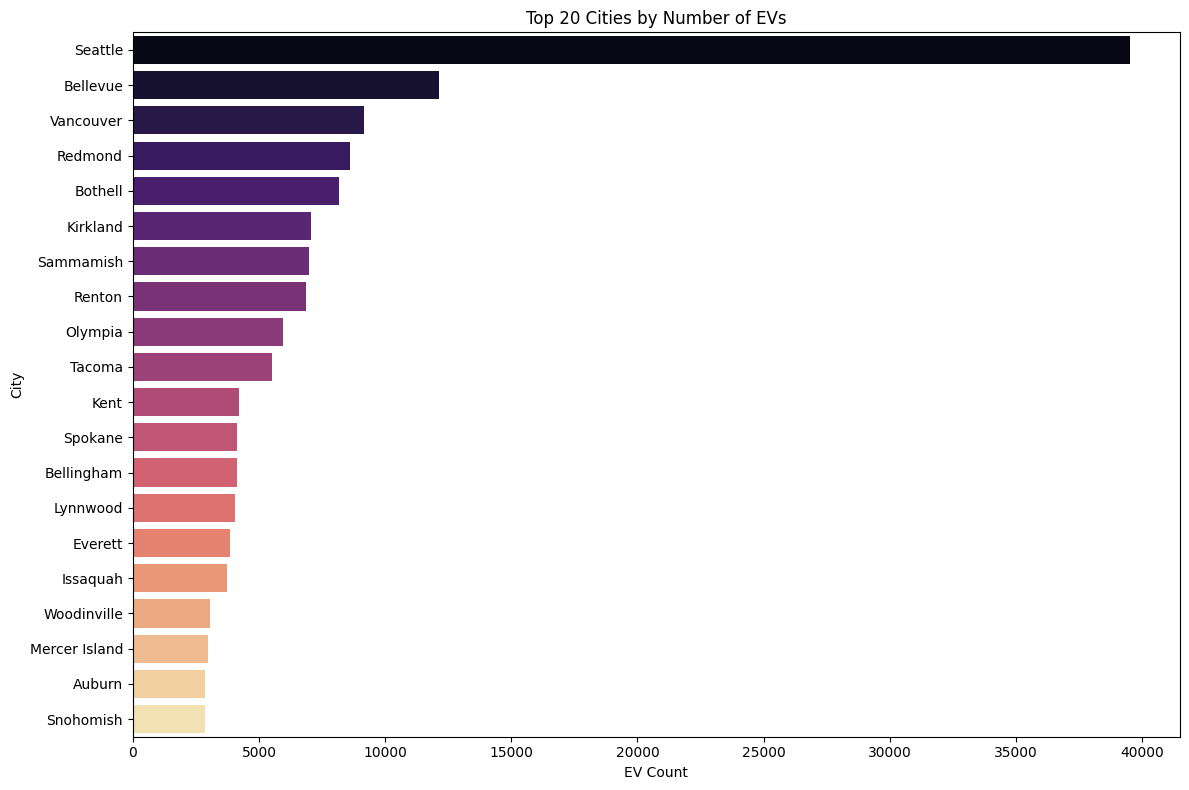

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort city counts for better visibility
top_cities = city_counts.sort_values('ev_count', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_cities, y='city', x='ev_count', palette='magma')
plt.title('Top 20 Cities by Number of EVs')
plt.xlabel('EV Count')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## Visualization of Postal Code Aggregation

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_60770/694010010.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_postals, x='postal_code', y='ev_count', palette='magma')


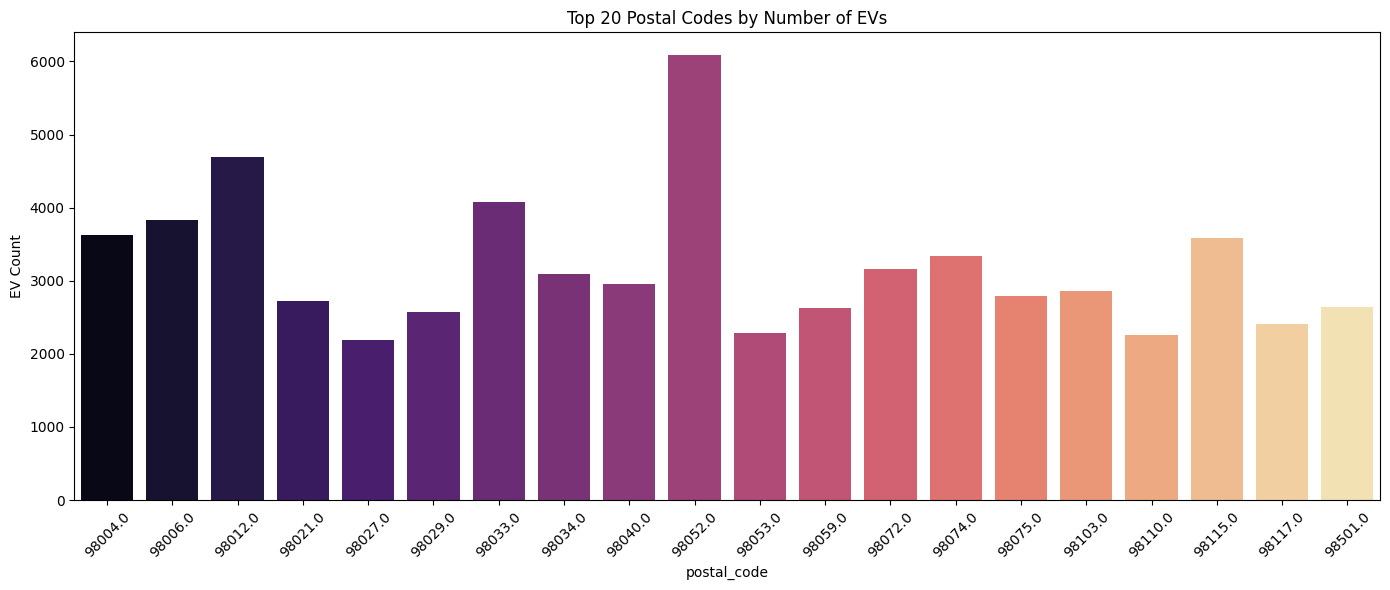

In [11]:
# Top 20 postal codes
top_postals = postal_counts.sort_values('ev_count', ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(data=top_postals, x='postal_code', y='ev_count', palette='magma')
plt.title('Top 20 Postal Codes by Number of EVs')
plt.xticks(rotation=45)
plt.ylabel('EV Count')
plt.tight_layout()
plt.show()

## Geo Binned Aggregation

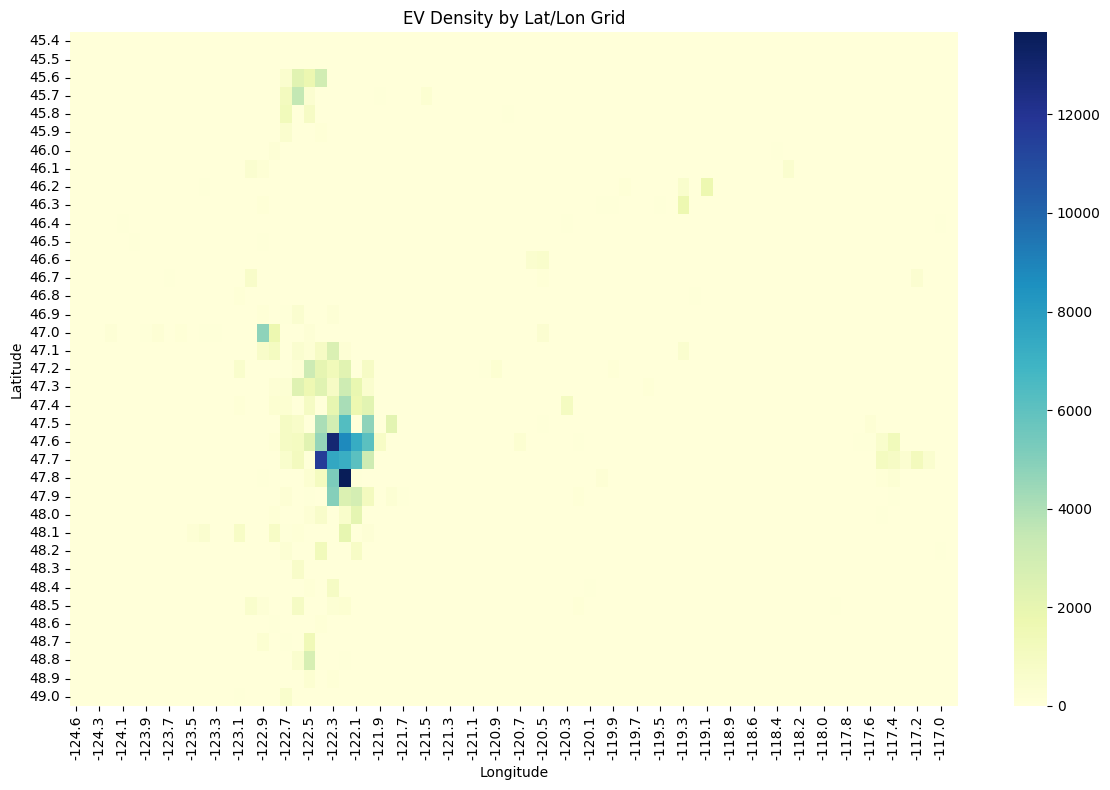

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table for heatmap
heatmap_data = geo_counts.pivot_table(index='lat_bin', columns='lon_bin', values='ev_count', fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('EV Density by Lat/Lon Grid')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## EV Density by Lat/Lon Grid

In [13]:
#pip install folium

In [14]:
import folium
from folium.plugins import HeatMap

# Create base map centered around WA state (or your dataset's mean lat/lon)
m = folium.Map(location=[ev_pop_df_cleaned['lat'].mean(), ev_pop_df_cleaned['lon'].mean()], zoom_start=7)

# Prepare data for heatmap: [lat, lon, weight]
heat_data = [[row['lat_bin'], row['lon_bin'], row['ev_count']] for index, row in geo_counts.iterrows()]

# Add heatmap layer
HeatMap(heat_data, radius=10, blur=15).add_to(m)

# Show map
m

In [15]:
#pip install keplergl

In [16]:
from keplergl import KeplerGl

# Create map
map_1 = KeplerGl(height=600)

# Add data (use full dataset or geo_counts)
map_1.add_data(data=geo_counts, name='EV Density by Grid')

# Display map
map_1

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'EV Density by Grid': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, …

## Adding Features to Each Region

In [17]:
# average electric range per postal code
avg_range = ev_pop_df_cleaned.groupby('postal_code')['electric_range'].mean().reset_index(name='avg_electric_range')

# BEV ratio per postal code
bev_ratio = ev_pop_df_cleaned.groupby('postal_code')['electric_vehicle_type'].apply(
    lambda x: (x == 'Battery Electric Vehicle (BEV)').mean()).reset_index(name='bev_ratio')

# Average base MSRP
avg_price = ev_pop_df_cleaned.groupby('postal_code')['base_msrp'].mean().reset_index(name='avg_base_msrp')

# Merge all features
features_df = postal_counts.merge(avg_range, on='postal_code', how='left') \
                       .merge(bev_ratio, on='postal_code', how='left') \
                       .merge(avg_price, on='postal_code', how='left')

## Adding Geolocation Information

In [18]:
# Take average location of EVs in that postal code
location = ev_pop_df_cleaned.groupby('postal_code')[['lat', 'lon']].mean().reset_index()
features_df = features_df.merge(location, on='postal_code', how='left')

## Creating the Target Variable for Classification

In [19]:
# Use quantiles to define demand categories (Low, Medium, High)
features_df['demand_level'] = pd.qcut(features_df['ev_count'], q=3, labels=['Low', 'Medium', 'High'])

In [20]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581 entries, 0 to 580
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   postal_code         581 non-null    float64 
 1   ev_count            581 non-null    int64   
 2   avg_electric_range  581 non-null    float64 
 3   bev_ratio           581 non-null    float64 
 4   avg_base_msrp       581 non-null    float64 
 5   lat                 581 non-null    float64 
 6   lon                 581 non-null    float64 
 7   demand_level        581 non-null    category
dtypes: category(1), float64(6), int64(1)
memory usage: 32.6 KB


## Class Balance of `demand_level`

/var/folders/vz/t7hhp_d94_x5_9qpjz3_2bf80000gn/T/ipykernel_60770/3227106056.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=features_df,


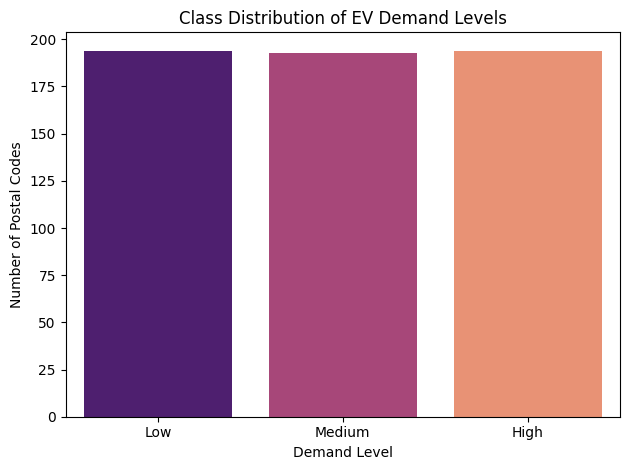

In [21]:
sns.countplot(data=features_df,
              x='demand_level',
              palette='magma')
plt.title("Class Distribution of EV Demand Levels")
plt.xlabel("Demand Level")
plt.ylabel("Number of Postal Codes")
plt.tight_layout()
plt.show()

## Correlation Heatmap of Numeric Features

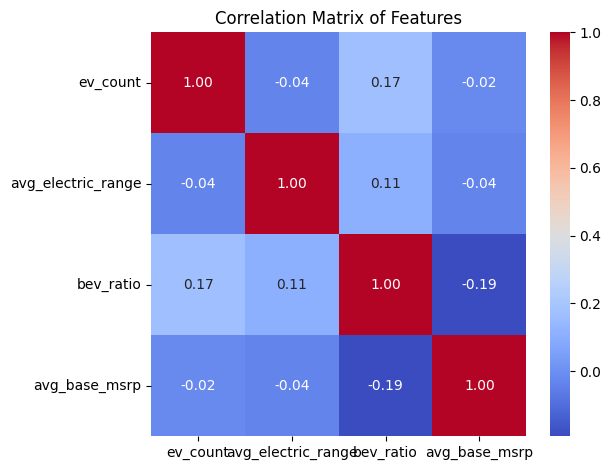

In [22]:
# Compute correlations
corr = features_df[['ev_count', 'avg_electric_range', 'bev_ratio', 'avg_base_msrp']].corr()

# Plot heatmap of correlations
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

## Distribution of EV Count (before regression)

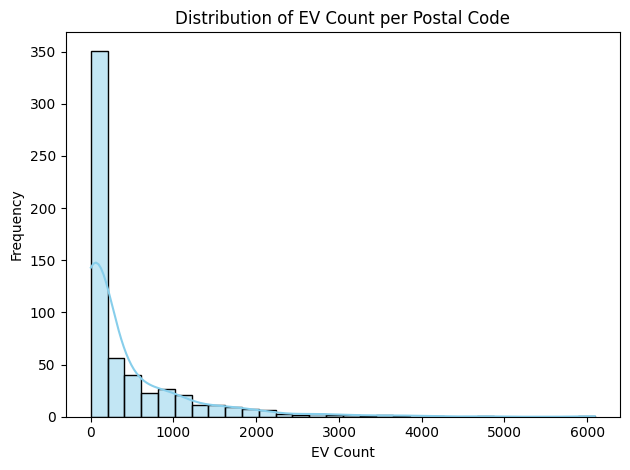

In [23]:
sns.histplot(features_df['ev_count'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of EV Count per Postal Code")
plt.xlabel("EV Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Geospatial Distribution (EV Count by Location)

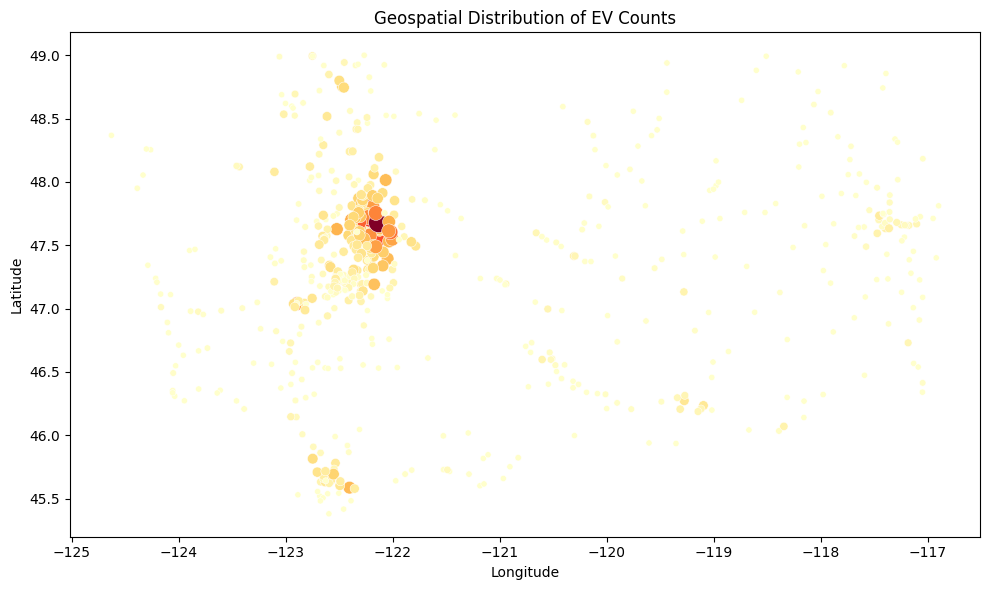

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=features_df, x='lon', y='lat', size='ev_count', hue='ev_count', sizes=(20, 200), palette='YlOrRd', legend=False)
plt.title("Geospatial Distribution of EV Counts")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## Normalizing the Skewness for `ev_count`

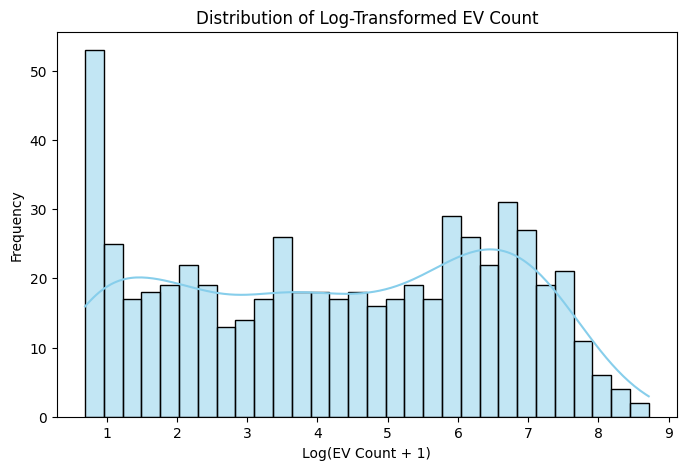

In [25]:
# Avoid log(0) by adding 1
features_df['log_ev_count'] = np.log1p(features_df['ev_count'])

# Visualization of the new distribution
plt.figure(figsize=(8,5))
sns.histplot(features_df['log_ev_count'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Log-Transformed EV Count')
plt.xlabel('Log(EV Count + 1)')
plt.ylabel('Frequency')
plt.show()

## Scaling the Features

In [26]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['avg_electric_range', 'avg_base_msrp', 'bev_ratio']
scaler = StandardScaler()
features_df[features_to_scale] = scaler.fit_transform(features_df[features_to_scale])